# Smart Material Planning: Backorder Prediction with Machine Learning

## Dataset Variables

### Numerical Variables

| Variable | Description |
|-----------|-------------|
| national_inv | Current national inventory available for the SKU. |
| lead_time | Supplier lead time in days. |
| in_transit_qty | Quantity currently in transit from suppliers. |
| forecast_3_month | Forecasted demand for the next 3 months. |
| forecast_6_month | Forecasted demand for the next 6 months. |
| forecast_9_month | Forecasted demand for the next 9 months. |
| sales_1_month | Sales during the previous month. |
| sales_3_month | Sales during the previous 3 months. |
| sales_6_month | Sales during the previous 6 months. |
| sales_9_month | Sales during the previous 9 months. |
| min_bank | Minimum inventory level required. |
| pieces_past_due | Quantity currently overdue from suppliers. |
| perf_6_month_avg | Average supplier performance over the last 6 months. |
| perf_12_month_avg | Average supplier performance over the last 12 months. |
| local_bo_qty | Quantity currently on local backorder. |

### Categorical Variables

| Variable | Description |
|-----------|-------------|
| sku | Unique Stock Keeping Unit identifier. |
| potential_issue | Indicates whether the SKU has a known supply issue. |
| deck_risk | Indicates whether the SKU is flagged as Deck Risk. |
| oe_constraint | Indicates whether Original Equipment constraints exist. |
| ppap_risk | Indicates whether the SKU is affected by PPAP (Production Part Approval Process) risk. |
| stop_auto_buy | Indicates whether automatic purchasing has been disabled. |
| rev_stop | Indicates whether the product is under revision stop. |
| went_on_backorder | Target variable indicating whether the SKU eventually experienced a backorder. |

## Data Cleaning and Preparation

### Import libraries

In [1]:
import pandas as pd
import numpy as np # Numerical operations
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns
from scipy import stats

In [2]:
pd.set_option("display.max_columns", None) # Display all columns when inspecting the dataset
pd.set_option("display.float_format", lambda x: f"{x:,.2f}") #Two decimals shown

### Load data

The project includes separate training and testing datasets.

In [3]:
train_path = "../data/raw/Training_BOP.csv"
test_path = "../data/raw/Testing_BOP.csv"

df_train = pd.read_csv(train_path, low_memory=False) #Inspects the entire file before assigning data types in both of the datasets
df_test = pd.read_csv(test_path, low_memory=False)

### Initial dataset inspection

In [4]:
print(f"Training dataset shape: {df_train.shape}")

Training dataset shape: (1687861, 23)


In [5]:
print(f"Testing dataset shape: {df_test.shape}")

Testing dataset shape: (242076, 23)


In [6]:
df_train.head()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,-99.00,-99.00,0.00,No,No,No,Yes,No,No
1,1043384,2.00,9.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,0.99,0.99,0.00,No,No,No,Yes,No,No
2,1043696,2.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,-99.00,-99.00,0.00,Yes,No,No,Yes,No,No
3,1043852,7.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,No,0.00,0.10,0.13,0.00,No,No,No,Yes,No,No
4,1044048,8.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,2.00,No,0.00,-99.00,-99.00,0.00,Yes,No,No,Yes,No,No


In [7]:
df_test.head()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,3285085,62.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,No,0.00,-99.00,-99.00,0.00,Yes,No,No,Yes,No,No
1,3285131,9.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,No,0.00,-99.00,-99.00,0.00,No,No,Yes,No,No,No
2,3285358,17.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,0.92,0.95,0.00,No,No,No,Yes,No,No
3,3285517,9.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,No,0.00,0.78,0.75,0.00,No,No,Yes,Yes,No,No
4,3285608,2.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,0.54,0.71,0.00,No,No,No,Yes,No,No


In [8]:
print("Training columns:")
print(df_train.columns.tolist())

Training columns:
['sku', 'national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']


In [9]:
print("Testing columns:")
print(df_test.columns.tolist())

Testing columns:
['sku', 'national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']


In [10]:
#Double check if they have the same columns

train_columns = set(df_train.columns)
test_columns = set(df_test.columns)

In [11]:
print("Columns only in training:")
print(train_columns - test_columns)

Columns only in training:
set()


In [12]:
print("Columns only in testing:")
print(test_columns - train_columns)

Columns only in testing:
set()


In [13]:
# 0 Diferences, all ok

### Dataset information

In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1687861 entries, 0 to 1687860
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   sku                1687861 non-null  object 
 1   national_inv       1687860 non-null  float64
 2   lead_time          1586967 non-null  float64
 3   in_transit_qty     1687860 non-null  float64
 4   forecast_3_month   1687860 non-null  float64
 5   forecast_6_month   1687860 non-null  float64
 6   forecast_9_month   1687860 non-null  float64
 7   sales_1_month      1687860 non-null  float64
 8   sales_3_month      1687860 non-null  float64
 9   sales_6_month      1687860 non-null  float64
 10  sales_9_month      1687860 non-null  float64
 11  min_bank           1687860 non-null  float64
 12  potential_issue    1687860 non-null  object 
 13  pieces_past_due    1687860 non-null  float64
 14  perf_6_month_avg   1687860 non-null  float64
 15  perf_12_month_avg  1687860 non-n

In [15]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242076 entries, 0 to 242075
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   sku                242076 non-null  object 
 1   national_inv       242075 non-null  float64
 2   lead_time          227351 non-null  float64
 3   in_transit_qty     242075 non-null  float64
 4   forecast_3_month   242075 non-null  float64
 5   forecast_6_month   242075 non-null  float64
 6   forecast_9_month   242075 non-null  float64
 7   sales_1_month      242075 non-null  float64
 8   sales_3_month      242075 non-null  float64
 9   sales_6_month      242075 non-null  float64
 10  sales_9_month      242075 non-null  float64
 11  min_bank           242075 non-null  float64
 12  potential_issue    242075 non-null  object 
 13  pieces_past_due    242075 non-null  float64
 14  perf_6_month_avg   242075 non-null  float64
 15  perf_12_month_avg  242075 non-null  float64
 16  lo

In [16]:
# Compare data types between datasets
dtype_comparison = pd.DataFrame({
    "train_dtype": df_train.dtypes,
    "test_dtype": df_test.dtypes
})

dtype_comparison

,train_dtype,test_dtype
sku,object,object
national_inv,float64,float64
lead_time,float64,float64
in_transit_qty,float64,float64
forecast_3_month,float64,float64
forecast_6_month,float64,float64
forecast_9_month,float64,float64
sales_1_month,float64,float64
sales_3_month,float64,float64
sales_6_month,float64,float64


In [17]:
# They are the same!

### Review if its real or synthetic data

In [18]:
# Inspect random records
df_train.sample(10, random_state=42)

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
732013,2079946,0.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,No,0.00,0.98,0.98,0.00,No,No,Yes,Yes,No,No
38200,1149690,16.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,No,0.00,0.70,0.75,0.00,No,No,No,Yes,No,No
1145713,1511794,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,No,0.00,0.92,0.96,0.00,Yes,No,Yes,Yes,No,No
1080013,1441480,3.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,No,0.00,0.62,0.62,0.00,Yes,No,No,Yes,No,No
1264726,2847275,8.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,-99.00,-99.00,0.00,Yes,No,No,No,No,No
66161,1177658,4.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,No,0.00,1.00,0.99,0.00,No,No,No,Yes,No,No
1217859,1589288,4.00,8.00,0.00,19.00,31.00,39.00,7.00,14.00,16.00,28.00,0.00,No,0.00,0.51,0.53,0.00,No,No,No,Yes,No,No
160190,1271727,3.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,0.99,0.98,0.00,No,No,No,Yes,No,No
390716,1738678,4.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,No,0.00,0.42,0.36,0.00,No,No,No,Yes,No,No
1564671,3159436,0.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,0.96,0.96,0.00,No,No,No,Yes,No,No


In [19]:
# Check missing values to assess data quality and realism
missing_train = df_train.isna().sum().sort_values(ascending=False)
missing_test = df_test.isna().sum().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "train_missing": missing_train,
    "test_missing": missing_test
})

missing_summary[missing_summary.sum(axis=1) > 0]

,train_missing,test_missing
lead_time,100894,14725
min_bank,1,1
potential_issue,1,1
rev_stop,1,1
stop_auto_buy,1,1
ppap_risk,1,1
oe_constraint,1,1
deck_risk,1,1
local_bo_qty,1,1
perf_12_month_avg,1,1


In [20]:
# Review target distribution to detect class imbalance
df_train["went_on_backorder"].value_counts()

went_on_backorder
No     1676567
Yes      11293
Name: count, dtype: int64

In [21]:
df_train["went_on_backorder"].value_counts(normalize=True) * 100

went_on_backorder
No    99.33
Yes    0.67
Name: proportion, dtype: float64

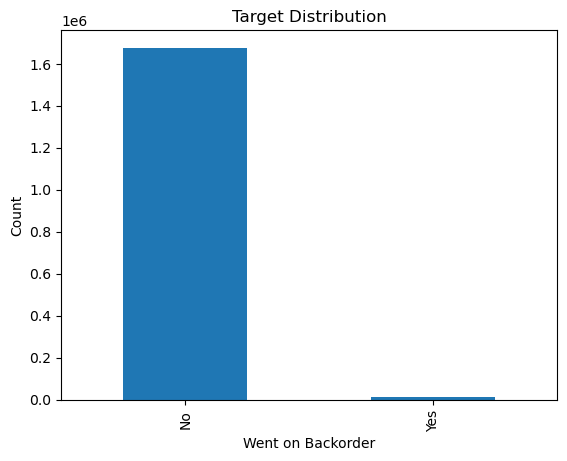

In [22]:
import matplotlib.pyplot as plt

df_train["went_on_backorder"].value_counts().plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("Went on Backorder")
plt.ylabel("Count")

plt.show()

In [23]:
# Check duplicated rows
print("Duplicated rows (train):", df_train.duplicated().sum())
print("Duplicated rows (test):", df_test.duplicated().sum())

Duplicated rows (train): 0
Duplicated rows (test): 0


In [24]:
numeric_cols = df_train.select_dtypes(include=["float64","int64"]).columns

df_train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
national_inv,"1,687,860.00",496.11,"29,615.23","-27,256.00",4.00,15.00,80.00,"12,334,404.00"
lead_time,"1,586,967.00",7.87,7.06,0.00,4.00,8.00,9.00,52.00
in_transit_qty,"1,687,860.00",44.05,"1,342.74",0.00,0.00,0.00,0.00,"489,408.00"
forecast_3_month,"1,687,860.00",178.12,"5,026.55",0.00,0.00,0.00,4.00,"1,427,612.00"
forecast_6_month,"1,687,860.00",344.99,"9,795.15",0.00,0.00,0.00,12.00,"2,461,360.00"
forecast_9_month,"1,687,860.00",506.36,"14,378.92",0.00,0.00,0.00,20.00,"3,777,304.00"
sales_1_month,"1,687,860.00",55.93,"1,928.20",0.00,0.00,0.00,4.00,"741,774.00"
sales_3_month,"1,687,860.00",175.03,"5,192.38",0.00,0.00,1.00,15.00,"1,105,478.00"
sales_6_month,"1,687,860.00",341.73,"9,613.17",0.00,0.00,2.00,31.00,"2,146,625.00"
sales_9_month,"1,687,860.00",525.27,"14,838.61",0.00,0.00,4.00,47.00,"3,205,172.00"


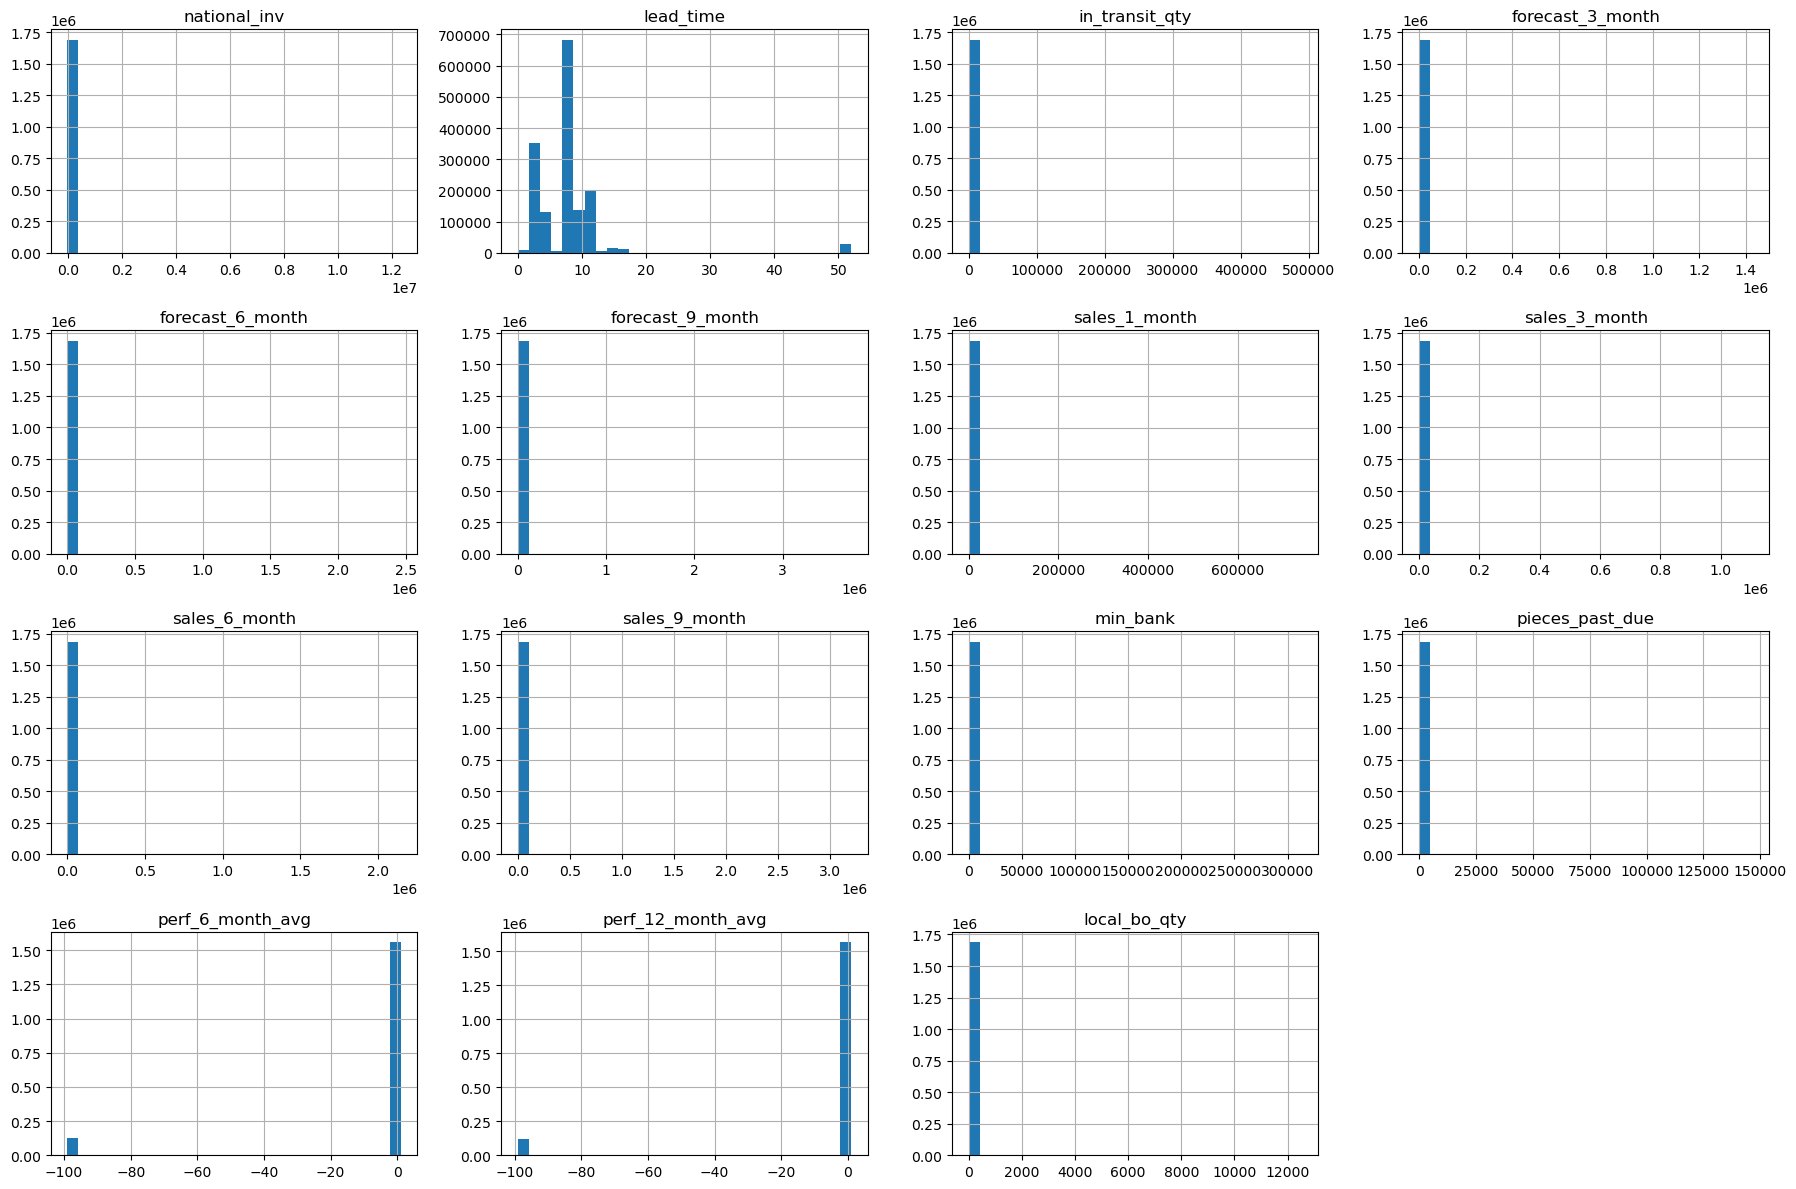

In [25]:
numeric_cols = df_train.select_dtypes(include=["float64","int64"]).columns

df_train[numeric_cols].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()
plt.show()

In [26]:
# Inspect random observations looking for realistic values
df_train.sample(10, random_state=42)

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
732013,2079946,0.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,No,0.00,0.98,0.98,0.00,No,No,Yes,Yes,No,No
38200,1149690,16.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,No,0.00,0.70,0.75,0.00,No,No,No,Yes,No,No
1145713,1511794,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,No,0.00,0.92,0.96,0.00,Yes,No,Yes,Yes,No,No
1080013,1441480,3.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,No,0.00,0.62,0.62,0.00,Yes,No,No,Yes,No,No
1264726,2847275,8.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,-99.00,-99.00,0.00,Yes,No,No,No,No,No
66161,1177658,4.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,No,0.00,1.00,0.99,0.00,No,No,No,Yes,No,No
1217859,1589288,4.00,8.00,0.00,19.00,31.00,39.00,7.00,14.00,16.00,28.00,0.00,No,0.00,0.51,0.53,0.00,No,No,No,Yes,No,No
160190,1271727,3.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,0.99,0.98,0.00,No,No,No,Yes,No,No
390716,1738678,4.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,No,0.00,0.42,0.36,0.00,No,No,No,Yes,No,No
1564671,3159436,0.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,No,0.00,0.96,0.96,0.00,No,No,No,Yes,No,No


- Training and testing datasets have the same structure, variables and data types.
- Missing values are minimal, except for lead_time, which contains a significant number of missing records.
- No duplicated rows were found in either dataset.
- The target variable is highly imbalanced (99.33% No vs. 0.67% Yes).
- Numerical variables show highly skewed distributions with extreme values.
- The dataset seems suitable for further statistical analysis and Machine Learning modeling.

## Exploratory Data Analysis (EDA)

### Recap from Dataset information that helps the EDA

- Backorders represent only **0.67%** of the training records.
- The target is highly imbalanced, with **99.33% No** and **0.67% Yes**. → This imbalance is plausible because backorders are relatively rare events.
- Accuracy will not be sufficient to evaluate the future models. → **Recall, precision, F1-score, PR-AUC, and the confusion matrix will be more relevant.**

### Numerical variables

In [27]:
# Select numerical features for operational analysis
numerical_features = [
    "national_inv",
    "lead_time",
    "in_transit_qty",
    "forecast_3_month",
    "forecast_6_month",
    "forecast_9_month",
    "sales_1_month",
    "sales_3_month",
    "sales_6_month",
    "sales_9_month",
    "min_bank",
    "pieces_past_due",
    "perf_6_month_avg",
    "perf_12_month_avg",
    "local_bo_qty"
]

#### Skewness

In [28]:
# Calculate skewness for each numerical variable
skewness_summary = pd.DataFrame({
    "skewness": df_train[numerical_features]
    .apply(lambda column: stats.skew(column.dropna()))
}).sort_values(
    by="skewness",
    ascending=False
)

skewness_summary

,skewness
pieces_past_due,412.39
national_inv,340.29
sales_1_month,196.12
in_transit_qty,166.18
local_bo_qty,165.19
forecast_9_month,143.30
sales_3_month,141.29
sales_6_month,139.18
forecast_3_month,138.97
forecast_6_month,138.96


- Most inventory, sales, and forecast variables are strongly right-skewed.
- Strong skewness must be considered during preprocessing and model selection.

In [31]:
# Calculate the percentage of zero values
zero_percentage = (
    df_train[numerical_features]
    .eq(0) # = 0?
    .mean()
    .mul(100) #Make it a %
    .sort_values(ascending=False)
)

In [32]:
zero_summary = zero_percentage.to_frame(
    name="zero_percentage"
)

zero_summary

,zero_percentage
local_bo_qty,98.62
pieces_past_due,98.50
in_transit_qty,79.67
forecast_3_month,69.78
forecast_6_month,64.23
forecast_9_month,61.22
sales_1_month,56.87
min_bank,51.68
sales_3_month,44.98
sales_6_month,38.33


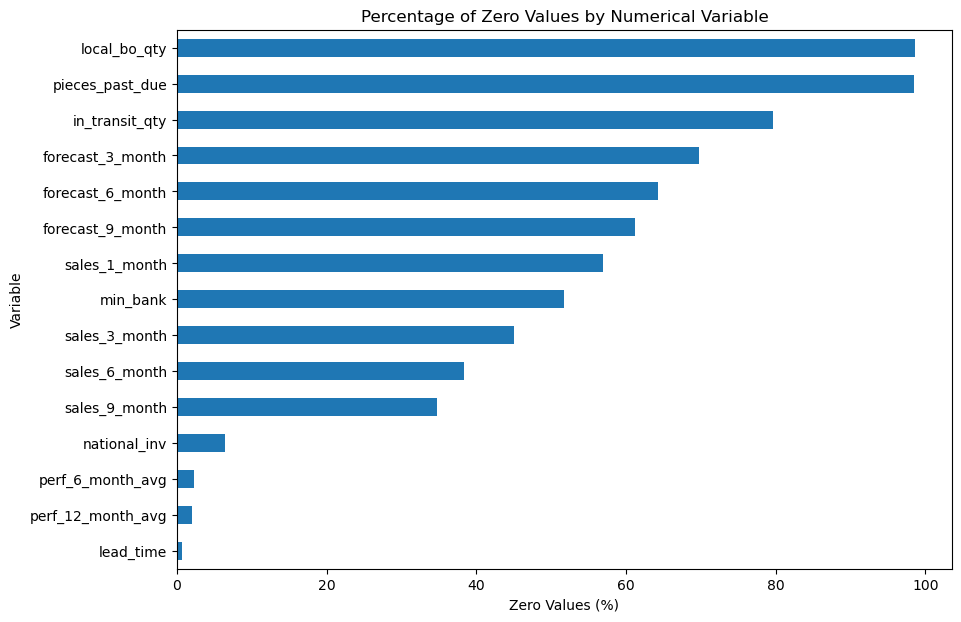

In [30]:
# Visualize zero concentration across numerical variables
plt.figure(figsize=(10, 7))

zero_percentage.sort_values().plot(
    kind="barh"
)

plt.title("Percentage of Zero Values by Numerical Variable")
plt.xlabel("Zero Values (%)")
plt.ylabel("Variable")

plt.show()

- Several operational variables contain a very high proportion of zero values.
- Zero values appear to represent valid business states rather than missing data.
- Local backorder quantity and past due pieces are zero for almost all observations.
- Sales and forecast variables also contain many zeros, indicating periods without demand.

#### Inventory distribution

In [33]:
# Limit the visualization to the 99th percentile
inventory_upper_limit = df_train["national_inv"].quantile(0.99)

In [34]:
inventory_plot = df_train.loc[
    df_train["national_inv"] <= inventory_upper_limit,
    "national_inv"
]

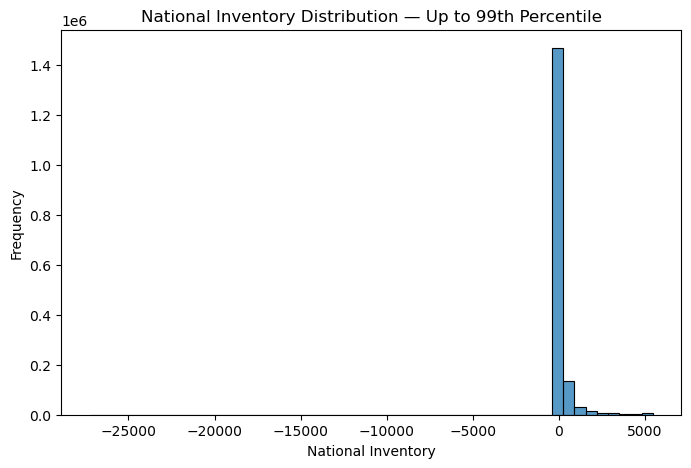

In [35]:
# Visualize national inventory distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    inventory_plot,
    bins=50
)

plt.title("National Inventory Distribution — Up to 99th Percentile")
plt.xlabel("National Inventory")
plt.ylabel("Frequency")

plt.show()

In [36]:
# Count records with negative inventory
negative_inventory = (
    df_train["national_inv"] < 0
).sum()

In [37]:
negative_inventory_percentage = (
    df_train["national_inv"] < 0
).mean() * 100

In [38]:
print(f"Negative inventory records: {negative_inventory:,}")
print(f"Negative inventory percentage: {negative_inventory_percentage:.2f}%")

Negative inventory records: 5,888
Negative inventory percentage: 0.35%


- National inventory is highly right-skewed.
- Most products have relatively low inventory levels.
- A small number of products contain very large inventory quantities.
- Only 0.35% of records contain negative inventory values.
- The origin of negative inventory values should be investigated during data cleaning before deciding whether they represent valid business cases or data quality issues.

#### Lead time distribution

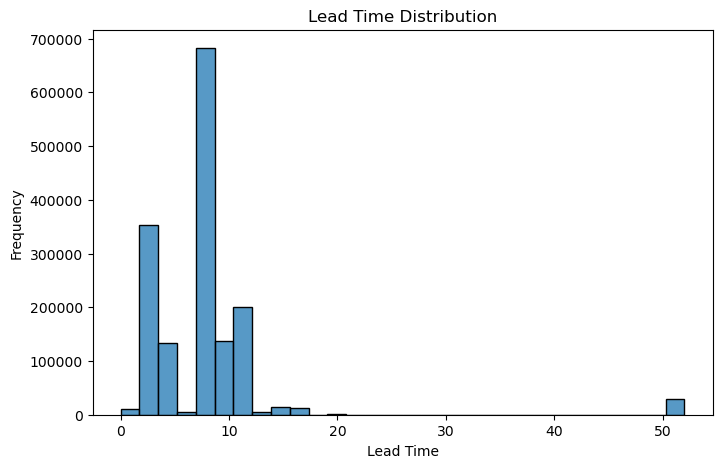

In [39]:
# Visualize supplier lead time distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_train,
    x="lead_time",
    bins=30
)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time")
plt.ylabel("Frequency")

plt.show()

In [40]:
# Review the most common lead-time values
df_train["lead_time"].value_counts(
    dropna=False
).head(15)

lead_time
8.00     682186
2.00     337402
12.00    199700
4.00     128537
9.00     123649
NaN      100894
52.00     30113
3.00      16253
10.00     14192
0.00      10511
14.00     10314
16.00      8843
13.00      5405
6.00       5365
5.00       4031
Name: count, dtype: int64

In [41]:
# Calculate missing lead-time percentage
lead_time_missing_percentage = (
    df_train["lead_time"]
    .isna()
    .mean()
    * 100
)

In [42]:
print(
    f"Missing lead-time percentage: "
    f"{lead_time_missing_percentage:.2f}%"
)

Missing lead-time percentage: 5.98%


- Lead time is concentrated between 2 and 12 days.
- Eight days is the most common supplier lead time.
- Approximately 6% of lead times are missing.

#### Supplier performance

In [47]:
# Quantify placeholder values in supplier performance variables
performance_columns = [
    "perf_6_month_avg",
    "perf_12_month_avg"
]

In [48]:
'''Since in data wranglingggling we found that the minimum value of perf_6_month_avg and 12 were -99 
I double check then to understand what to do with them when cleaning'''

placeholder_summary = pd.DataFrame({
    "minus_99_count": [
        (df_train[column] == -99).sum() #Count how many contain this value
        for column in performance_columns
    ],
    "minus_99_percentage": [
        (df_train[column] == -99).mean() * 100 #Review the % of how many contain this value
        for column in performance_columns
    ]
}, index=performance_columns)


In [49]:
placeholder_summary

,minus_99_count,minus_99_percentage
perf_6_month_avg,129478,7.67
perf_12_month_avg,122050,7.23


- Both performance variables contain a considerable number of **-99** values (around 7% of observations).
- The value **-99** appears to be a placeholder rather than a valid performance measurement.
- Placeholder values should be investigated during data cleaning before modelling.

### Categorical variables

In [43]:
# Select categorical operational features
categorical_features = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop"
]

In [44]:
# Review category values and frequencies
for column in categorical_features:
    print(f"\n{column}")
    print(df_train[column].value_counts(dropna=False))


potential_issue
potential_issue
No     1686953
Yes        907
NaN          1
Name: count, dtype: int64

deck_risk
deck_risk
No     1300377
Yes     387483
NaN          1
Name: count, dtype: int64

oe_constraint
oe_constraint
No     1687615
Yes        245
NaN          1
Name: count, dtype: int64

ppap_risk
ppap_risk
No     1484026
Yes     203834
NaN          1
Name: count, dtype: int64

stop_auto_buy
stop_auto_buy
Yes    1626774
No       61086
NaN          1
Name: count, dtype: int64

rev_stop
rev_stop
No     1687129
Yes        731
NaN          1
Name: count, dtype: int64


In [45]:
# Review category percentages
for column in categorical_features:
    print(f"\n{column}")
    
    percentages = (
        df_train[column]
        .value_counts(normalize=True, dropna=False) #Get the proportions
        .mul(100) #Make it %
        .round(2)
    )
    
    print(percentages)


potential_issue
potential_issue
No    99.95
Yes    0.05
NaN    0.00
Name: proportion, dtype: float64

deck_risk
deck_risk
No    77.04
Yes   22.96
NaN    0.00
Name: proportion, dtype: float64

oe_constraint
oe_constraint
No    99.99
Yes    0.01
NaN    0.00
Name: proportion, dtype: float64

ppap_risk
ppap_risk
No    87.92
Yes   12.08
NaN    0.00
Name: proportion, dtype: float64

stop_auto_buy
stop_auto_buy
Yes   96.38
No     3.62
NaN    0.00
Name: proportion, dtype: float64

rev_stop
rev_stop
No    99.96
Yes    0.04
NaN    0.00
Name: proportion, dtype: float64


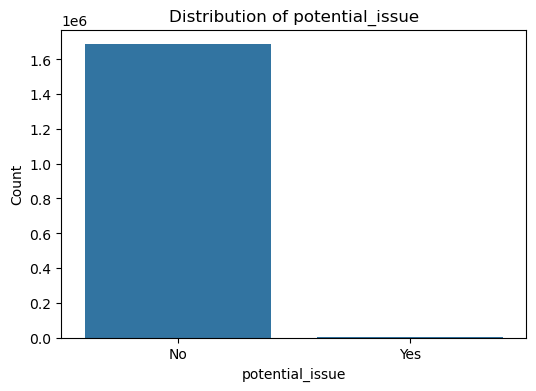

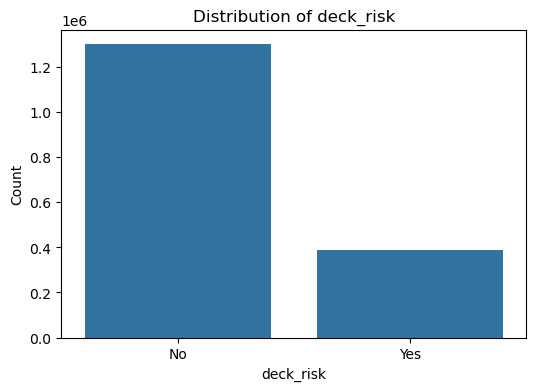

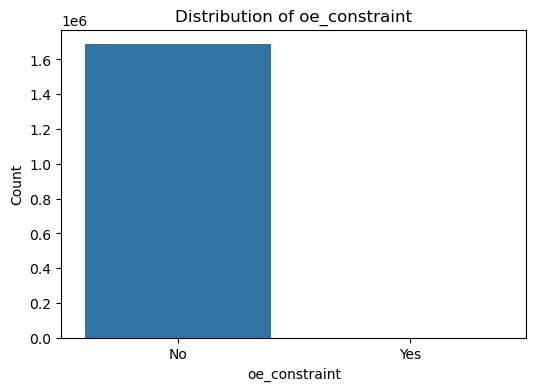

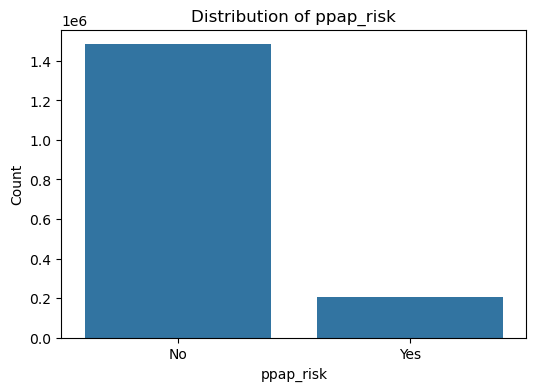

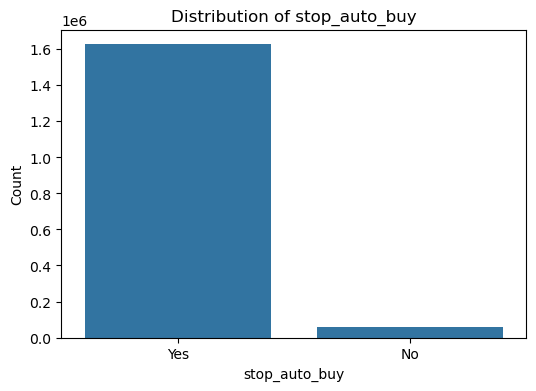

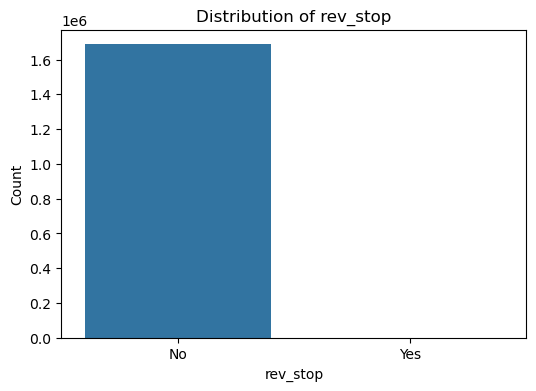

In [46]:
# Visualize categorical feature distributions
for column in categorical_features:
    plt.figure(figsize=(6, 4))

    sns.countplot(
        data=df_train,
        x=column
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.show()

- Most operational flags are highly unbalanced.
- Some events, such as potential issues or engineering constraints, occur very rarely.
- These variables may still provide strong predictive signals despite their low frequency.

### Correlation Analysis

In [50]:
# Calculate correlation matrix for numerical variables
correlation_matrix = df_train[numeric_cols].corr()

correlation_matrix

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty
national_inv,1.00,0.00,0.10,0.08,0.08,0.08,0.15,0.19,0.23,0.24,0.40,0.03,-0.01,-0.01,0.01
lead_time,0.00,1.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.00,-0.10,-0.11,-0.00
in_transit_qty,0.10,-0.01,1.00,0.66,0.69,0.68,0.62,0.70,0.69,0.66,0.75,0.17,0.00,0.00,0.07
forecast_3_month,0.08,-0.01,0.66,1.00,0.99,0.98,0.68,0.78,0.84,0.83,0.73,0.36,0.01,0.01,0.04
forecast_6_month,0.08,-0.01,0.69,0.99,1.00,0.99,0.70,0.81,0.87,0.86,0.74,0.36,0.01,0.01,0.04
forecast_9_month,0.08,-0.01,0.68,0.98,0.99,1.00,0.72,0.83,0.89,0.88,0.74,0.37,0.01,0.01,0.04
sales_1_month,0.15,-0.01,0.62,0.68,0.70,0.72,1.00,0.92,0.87,0.82,0.76,0.25,0.00,0.00,0.07
sales_3_month,0.19,-0.01,0.70,0.78,0.81,0.83,0.92,1.00,0.98,0.93,0.86,0.30,0.00,0.00,0.07
sales_6_month,0.23,-0.01,0.69,0.84,0.87,0.89,0.87,0.98,1.00,0.97,0.84,0.32,0.00,0.00,0.06
sales_9_month,0.24,-0.01,0.66,0.83,0.86,0.88,0.82,0.93,0.97,1.00,0.80,0.32,0.00,0.00,0.05


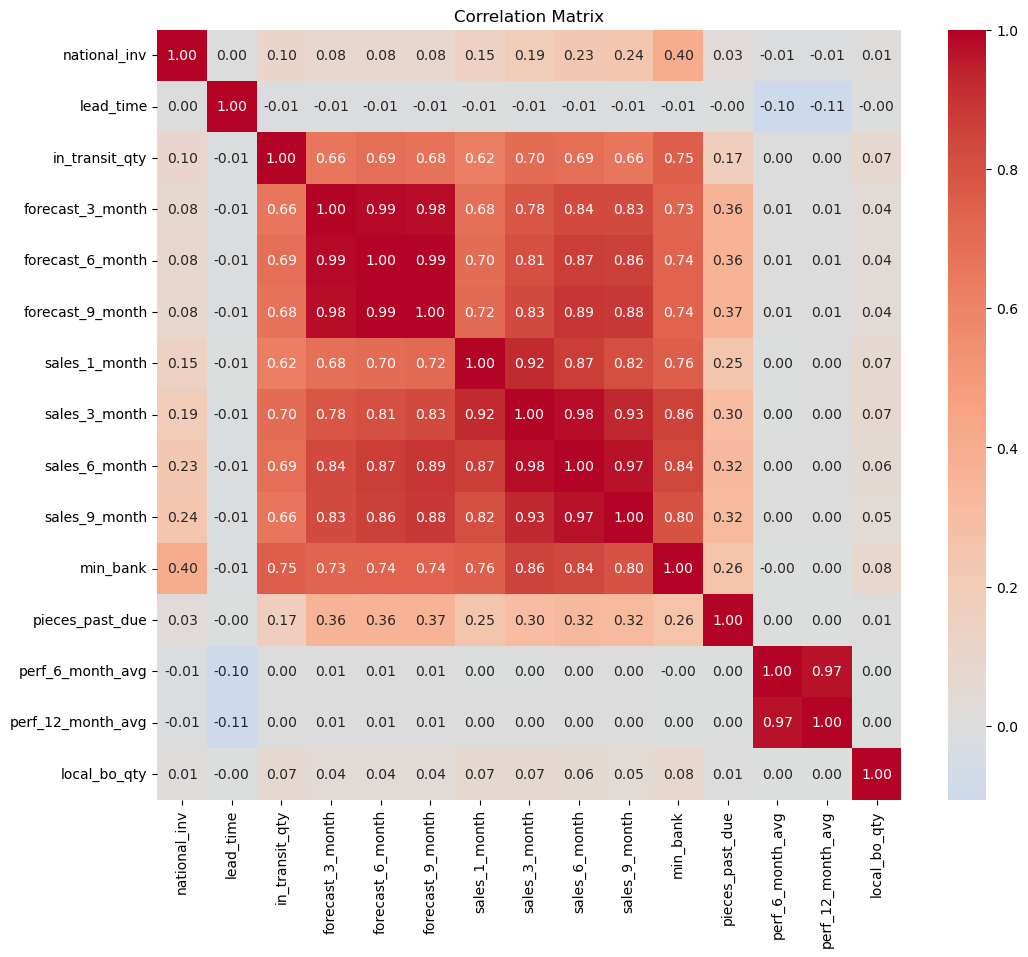

In [51]:
# Visualize correlations between numerical variables
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

- Forecast variables are highly correlated with each other (0.98–0.99), indicating potential redundancy.
- Historical sales variables also present very strong positive correlations across different time windows.
- Forecast and sales variables are moderately to strongly correlated, suggesting that demand forecasts are closely related to historical sales.
- Supplier performance metrics (6 and 12 months) show almost identical behaviour (0.97 correlation).
- Lead time shows little correlation with the remaining numerical variables, indicating it may provide independent predictive information.
- Inventory and local backorder quantities present relatively weak correlations with most variables.
- Highly correlated features will be reviewed later during feature engineering to avoid unnecessary redundancy.

## Final summary

The dataset presents a high overall data quality and appears suitable for Machine Learning.

The main data preparation tasks identified during the exploratory analysis are:

- Handle missing lead time values.
- Replace placeholder values (-99) in supplier performance variables.
- Investigate negative inventory observations.
- Preserve operational zero values where appropriate.
- Address severe class imbalance during modelling.

No duplicated records or major structural inconsistencies were identified.

Several groups of numerical variables show high correlation, particularly forecasts, historical sales and supplier performance metrics.